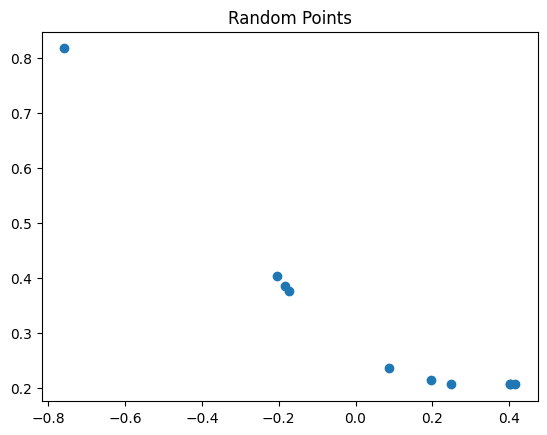

In [71]:
import numpy as np
import matplotlib.pyplot as plt
dof = 10
x = np.random.randn(dof)/2 # np.arange(10)
def make_polynomial(vector, _dof=None):
    if not _dof: _dof = dof
    b = vector.shape[0]
    return np.cumprod(np.concatenate([np.ones((b, 1)), vector.reshape(-1, 1).repeat(_dof-1, axis=1)], axis=1), axis=1)
Z = make_polynomial(x, 10)
d = Z @ np.random.randn(10)
plt.title("Random Points")
plt.scatter(x, d)

0.9041344069932309x^0+-0.23566159772655537x^1+-1.2953029323727876x^2+1.6306981016700626x^3+-0.12006829382725216x^4+1.61292660077032x^5+1.6862716585657247x^6+0.2528834573024145x^7+-0.43411963924679675x^8+1.6519286333532996x^9
loss(model).mean()=0.25316839922714535


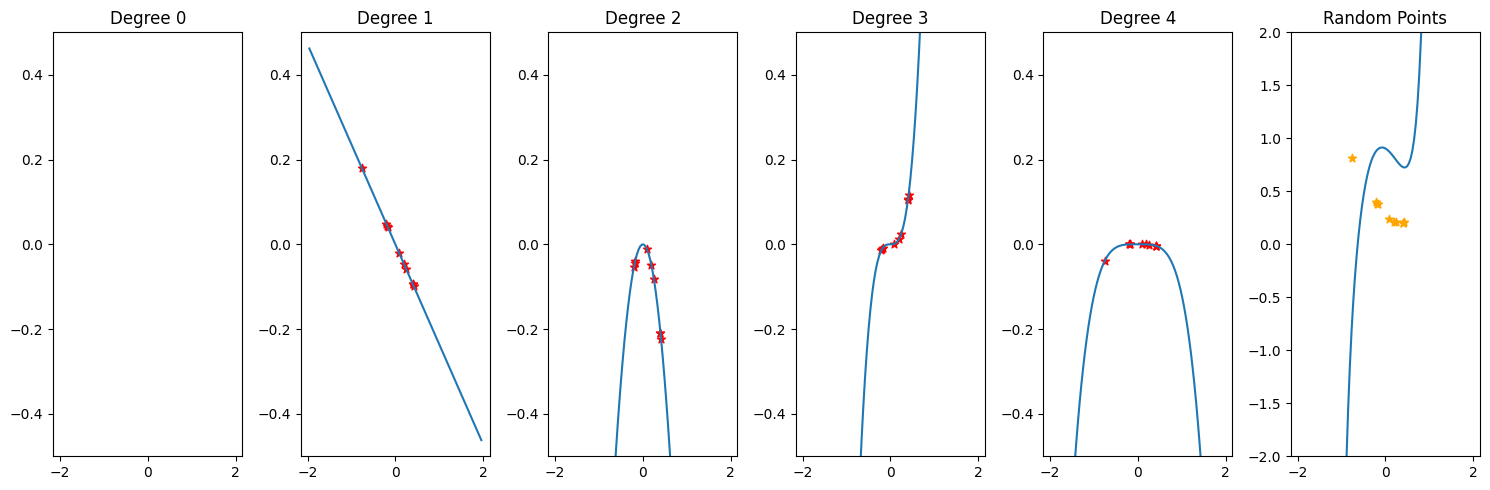

In [72]:
model = np.random.randn(dof)
print("+".join([f"{pi}x^{degree}" for degree, pi in enumerate(model)]))
def loss(model): return 0.5 * (Z @ model  - d) ** 2
print(f"{loss(model).mean()=}")

def make_polynomial_plot(model, x, d, dof=10, total_plots=5):
    fig, ax = plt.subplots(1, total_plots+1, figsize=(15, 5))
    space = np.linspace(-1.96, 1.96, 100) # 2sigma?
    for degree in range(dof)[:total_plots]:
        pi = model[degree]
        graph = space ** degree * pi
        ax[degree].plot(space, graph)
        ax[degree].scatter(x, pi * x ** degree, marker="*", color="r")
        ax[degree].set_title(f"Degree {degree}")
        ax[degree].set_ylim(-0.5, 0.5)
    ax[total_plots].set_title("Random Points")
    ax[total_plots].plot(space, make_polynomial(space, dof) @ model)
    ax[total_plots].scatter(x, d, marker="*", color="orange")
    ax[total_plots].set_ylim(-2, 2)
    fig.tight_layout()
    return

_ = make_polynomial_plot(model, x, d)

0.09680645087779804
0.06874757883065688
0.05249531288926933
0.04120952484642651
0.033077259604039386
0.027158135978961672
0.022820921273189753
0.01961897631426243
0.017233390990657176
0.015436062672022011
0.01406373982241963
0.012999521765991506
0.012159642954178198
0.011484028650431254
0.010929545226469245
0.010465176070182432
0.010068573613589718
0.00972359480337486
0.009418539394474046
0.009144890526467492


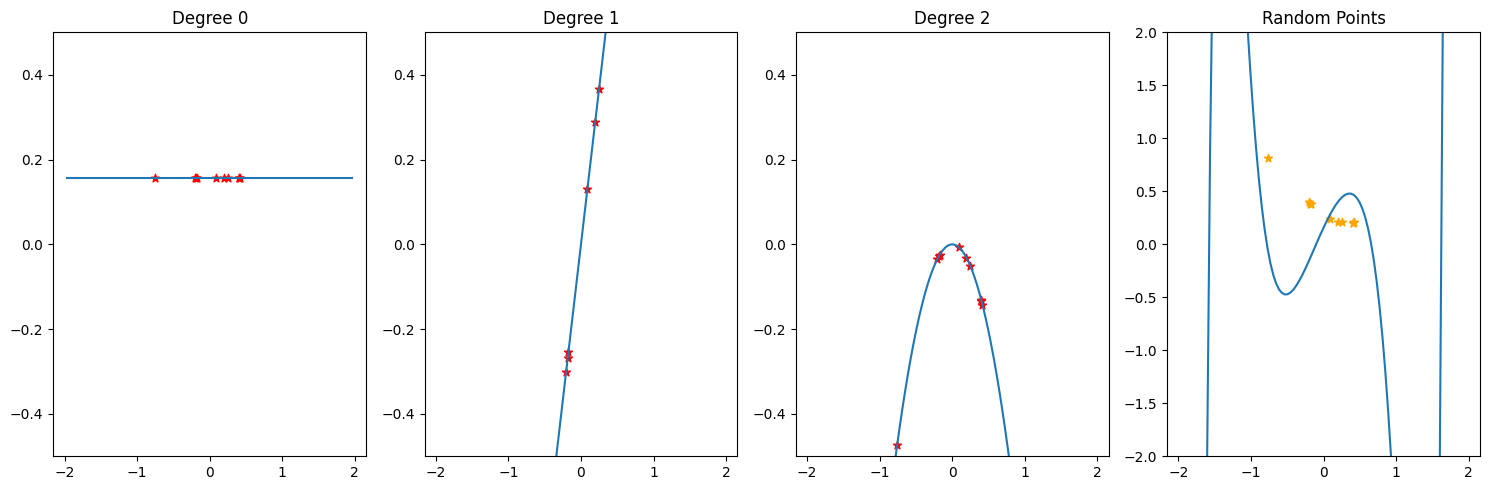

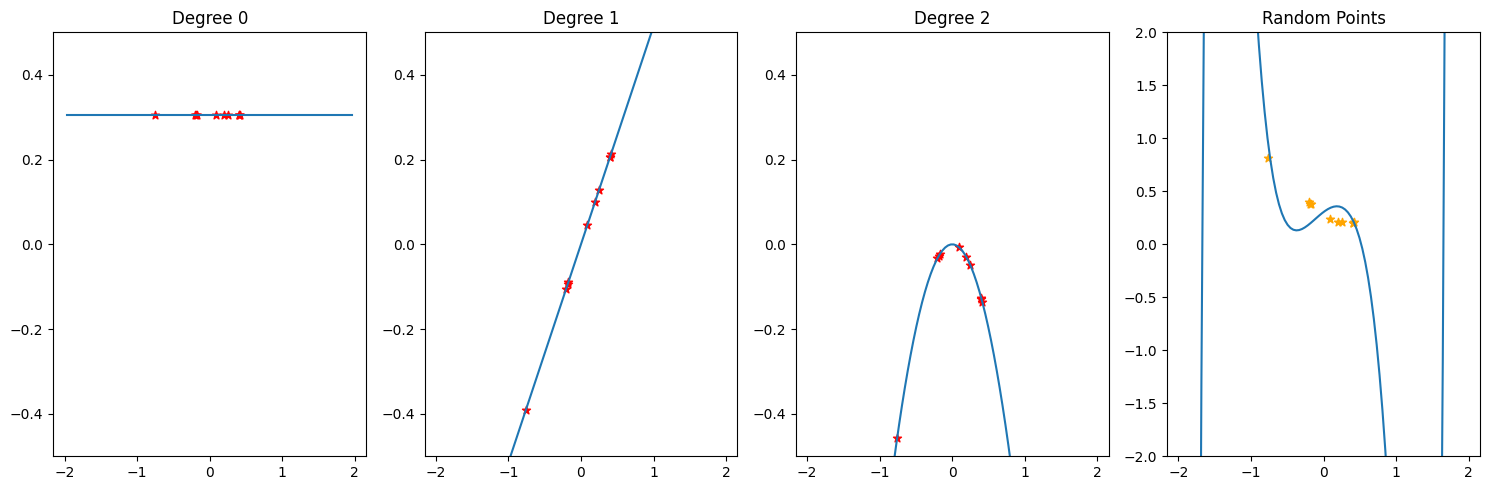

In [73]:
# minimize 1/2(model(Z)-d)^2
# dL/dw => below ((Z @ model - d) * Z).mean(axis=0)
model = np.random.randn(10)
alpha = 0.1
make_polynomial_plot(model, x, d, total_plots=3)
for i in range(200):
    if i % 10 == 0:
        print(loss(model).mean())
    model -= alpha * ((Z @ model - d).reshape(-1, 1) * Z).mean(axis=0)
make_polynomial_plot(model, x, d, total_plots=3)

**simplify the situation here, for getting insights.**

find the 1 degree of polynomial line crossing (0, 1) (1, 0).

$f(w) = 0.25 \times ((p_0-1)^2+(p_0+p_1-0)^2) = 0.5 \times w^T A w - b^Tw + C$

where, w=coeff; A=[[4, 2], [2, 2]]; b=[2, 0]

In [74]:
x = np.array([0, 1])
y = np.array([1, 0])
Z = make_polynomial(x, _dof=2)
w = np.random.randn(2) # coefficients of polynomial
A = np.array([[2, 1], [1, 1]]) / 2
b = np.array([1, 0]) / 2
Ainv = np.linalg.inv(A)
eigval, eigvec = np.linalg.eig(A) # Q \lambda Q^T -> ECA

As we get $\nabla f(w)=Aw-b$, $w^*=A^{-1}b$

In [75]:
w_optimal = Ainv @ b
w_optimal

array([ 1., -1.])

In [76]:
eigvec, eigval, eigvec.T @ eigvec

A @ eigvec, eigvec @ np.diag(eigval)

(array([[ 1.11351636, -0.10040571],
        [ 0.68819096,  0.16245985]]),
 array([[ 1.11351636, -0.10040571],
        [ 0.68819096,  0.16245985]]))

In [77]:
alpha = 0.1
w0 = w
x0 = eigvec.T @ (w0-w_optimal) # deformation along the eigvector
w1 = w0 - alpha * (A @ w0 - b)
x1 = eigvec.T @ (w1-w_optimal)
w2 = w1 - alpha * (A @ w1 - b)
x2 = eigvec.T @ (w2-w_optimal)

np.allclose(x0 * (1-alpha*eigval), x1), np.allclose(x0 * (1-alpha*eigval)**2, x2)

(True, True)

In [78]:
np.allclose(w1, w0 - alpha * ((Z @ w0 - y).reshape(-1, 1) * Z).mean(axis=0))

True

Text(0.5, 1.0, 'Exponential Shrink Rate')

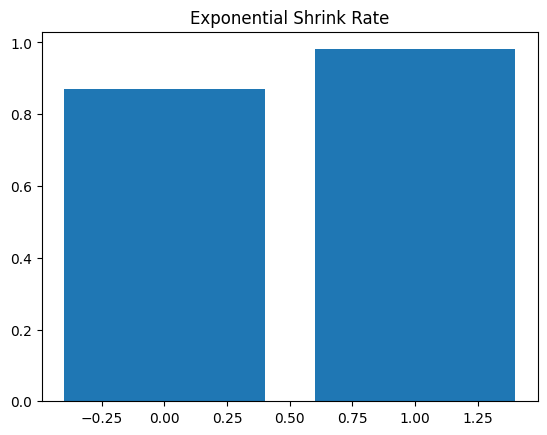

In [79]:
plt.bar(range(2), (1-alpha*eigval))
plt.title("Exponential Shrink Rate")

Text(0.5, 1.0, 'Exponential Shrink Rate, alpha is optimal')

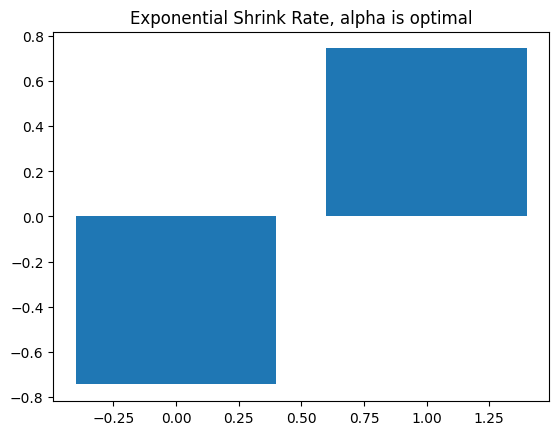

In [80]:
alpha_optimal = 2 / (eigval[0] + eigval[1])
plt.bar(range(2), (1-alpha_optimal*eigval))
plt.title("Exponential Shrink Rate, alpha is optimal")

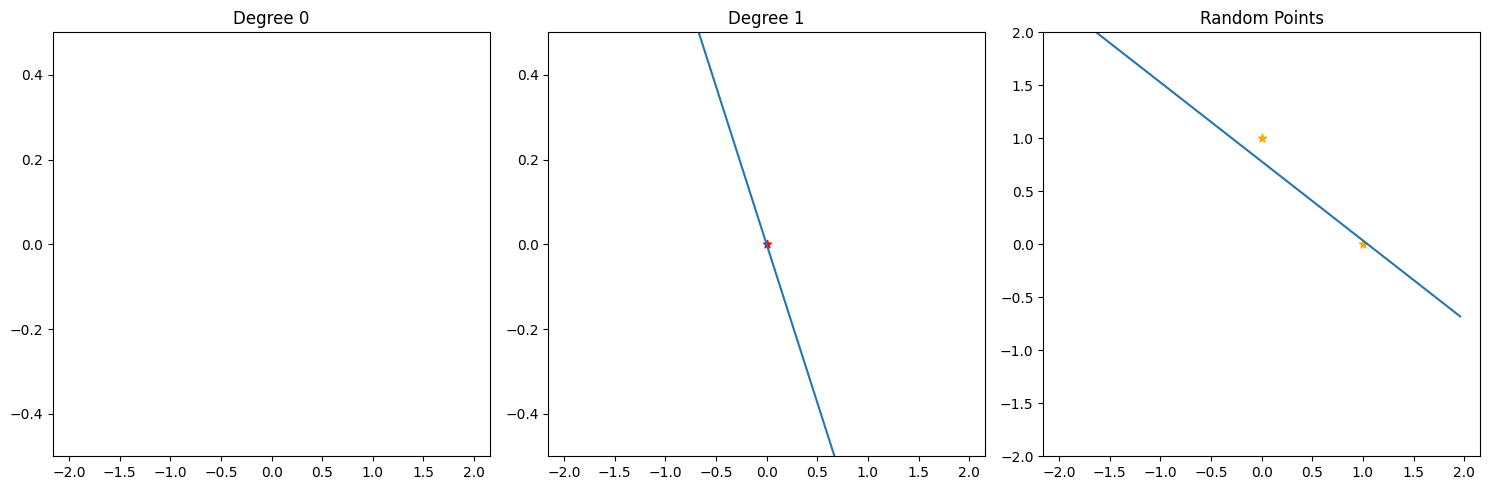

In [81]:
ww = w0.copy()
for i in range(7):
    ww -= alpha_optimal * (A @ ww - b)
make_polynomial_plot(ww, x, y, dof=2, total_plots=2)

**Extend to Nth polynomial data**

Following FFT's idea we get (n^2->nlogn), but we can do more with O(1). How is it possible? This is math not algorithm.

In 2 dimensional A, we can easily get a coeff landscape information. How to extend to N data points specified? -> 이항정리

- Calculate A, b ~ N^3
- Calculate Eigvector ~ QR Decomposition

We get kth gradient descent product with closed-form expression. Despite of some costy preparations... ORR Calculate the w_optimal for happiness!

In [104]:
dof = 10
x = np.random.randn(dof)/2
Z = make_polynomial(x, dof)
d = Z @ np.random.randn(10)

A = (Z.T @ Z) / dof
b = Z.T @ d / dof
eigval,eigvec = np.linalg.eig(A)
w_optimal = np.linalg.inv(A) @ b
np.allclose(eigvec @ np.diag(1/eigval) @ eigvec.T, np.linalg.inv(A))

True

In [105]:
(1-alpha_optimal*eigval)

array([-0.10584633,  0.83387976,  0.98776346,  0.99882617,  0.9999103 ,
        0.99999553,  0.99999994,  0.99999999,  1.        ,  1.        ])

Text(0.5, 1.0, 'Exponential Shrink Rate, blue: alpha is optimal')

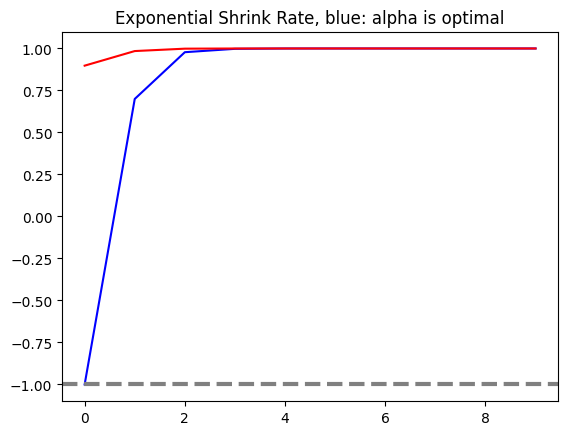

In [106]:
alpha_optimal = 2 / (eigval[0] + eigval[-1])
plt.plot(range(10), 1-alpha_optimal*eigval, color="b")
plt.plot(range(10), 1-0.1*eigval, color="r")
plt.axhline(-1, 0, 1, color='gray', linestyle='--', linewidth=3)
plt.title("Exponential Shrink Rate, blue: alpha is optimal")

In [107]:
w0 = np.random.randn(dof)
k = 5000
x0 = eigvec.T @ (w0-w_optimal) # deformation along the eigvector
xk = x0 * (1-alpha_optimal*eigval) ** k
wk = eigvec @ xk + w_optimal

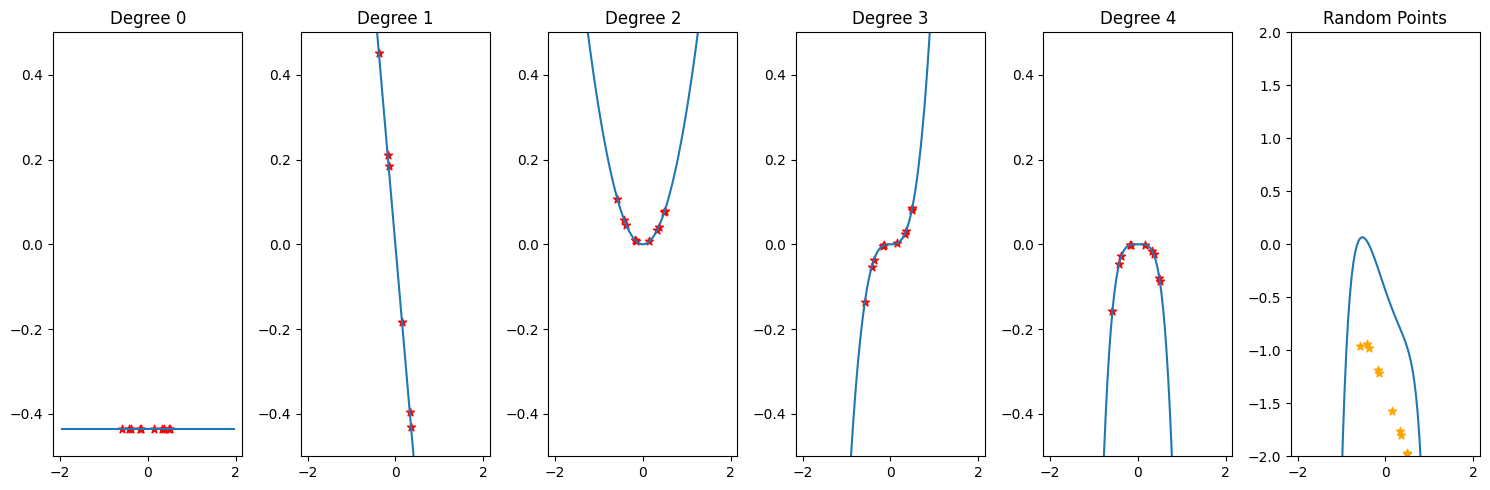

In [108]:
make_polynomial_plot(wk, x, d, dof)

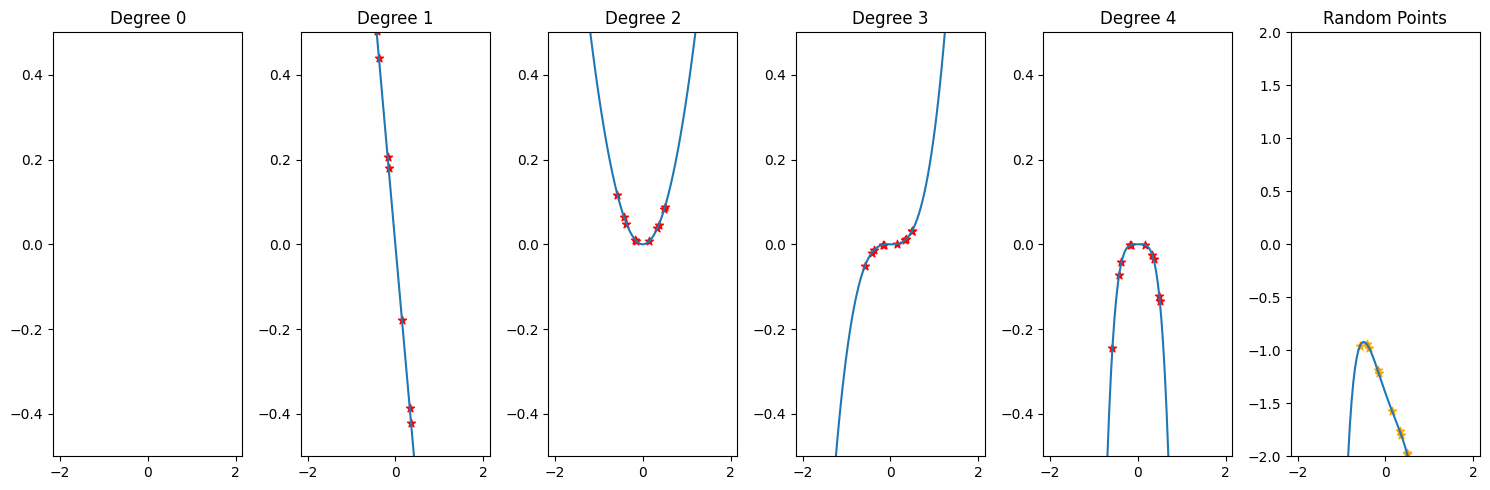

In [109]:
make_polynomial_plot(w_optimal, x, d, dof)

True


(array([1.+0.j, 2.+0.j, 3.+0.j, 4.+0.j]),
 array([1.+0.000000e+00j, 2.-6.123234e-17j, 3.+0.000000e+00j,
        4.+6.123234e-17j], dtype=complex64))

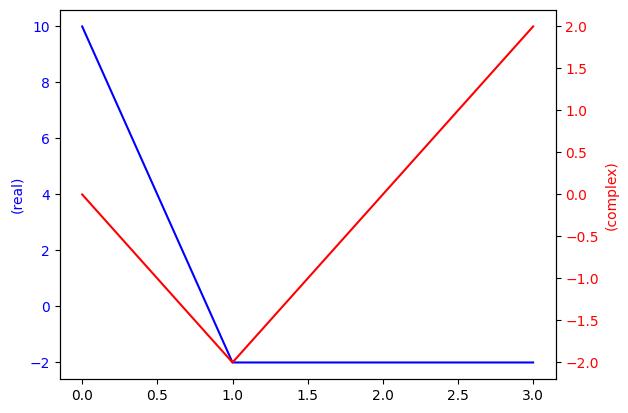

In [218]:
import math
## FFT - https://numpy.org/doc/2.2/reference/routines.fft.html
### odd/even function decomposition
# f(w) +w g(w) or f(w) -w g(w)
# frequency space <-> signal space
def get_w(theta):
    return np.cos(theta) + np.sin(theta) * 1j

def ft(coeff):
    rank = len(coeff)
    theta = 2 * math.pi / rank
    H = make_polynomial(get_w(np.arange(rank) * theta), rank)
    return H @ coeff

def fft(coeff, start=True, inverse=False):
    rank = len(coeff)
    if start:
        pad = 2 ** math.ceil(math.log2(rank))
        coeff = np.pad(coeff, (0, pad-rank), mode="constant", constant_values=0)
    padded_coeff_rank = len(coeff)
    w = get_w(2 * math.pi / len(coeff))
    w = 1 / w if inverse else w # Hf
    if len(coeff) == 1:
        return coeff
    even = fft(coeff[::2], start=False)
    odd = fft(coeff[1::2], start=False)

    frequencies = np.zeros(padded_coeff_rank, dtype=np.complex64)
    half = padded_coeff_rank // 2
    for i in range(half):
        frequencies[i] = even[i] + w ** i * odd[i]
        frequencies[i + half] = even[i] - w ** i * odd[i]
    if start:
        divider = 1
        if inverse:
            divider = padded_coeff_rank # Hermitian operation
        return frequencies[:rank] / divider
    return frequencies

coeff = np.array([1, 2, 3, 4])
print(np.allclose(ft(coeff), fft(coeff)))

fig, ax1 = plt.subplots()
ax1.plot(range(len(coeff)), fft(coeff).real, color="blue", label="real")
ax1.set_ylabel('(real)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
ax2.plot(range(len(coeff)), (-fft(coeff) * 1j).real, color="red", label="complex")
ax2.set_ylabel('(complex)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

np.fft.ifft(np.fft.fft(coeff)), fft(fft(coeff), inverse=True)

Text(0.5, 1.0, 'Linear System Overview')

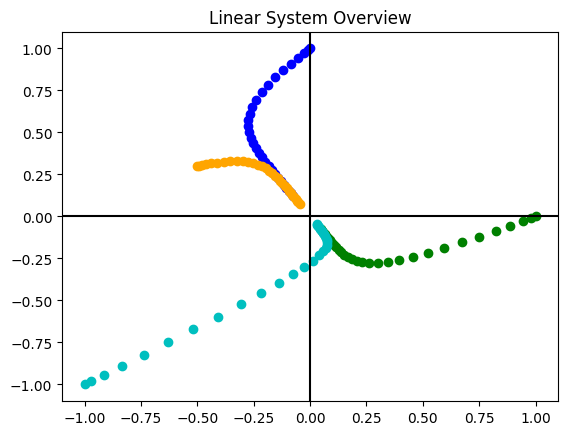

In [172]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Differential Equation => Iterative Gradient Descent
#       gradient = Ax (if b=0)
# x' = -2x -1y
# y' = -1x -1y
# e^{Rt} => position after time t passed.
R = np.array([[-2, -1], [-1, -1]], dtype=np.float64)
eigval, eigvec = np.linalg.eig(R)
# R /= np.linalg.norm(R, axis=0)

def exp_of_matrix(A, t):
    result = np.zeros_like(A, dtype=np.float64)
    for i in range(10): # taylor expansion
        result += t**i * np.linalg.matrix_power(A, i) / np.cumprod(np.arange(1, max(1, i)+1))[-1]
    return result

def get_trajectory(pos_initial, color):
    poses = []
    poses.append(pos_initial)
    for i in range(30):
        t = (i+1)/100
        # Rt = exp_of_matrix(R, t)
        Rt = expm(R*t)
        pos_t = Rt @ poses[-1]
        poses.append(pos_t)
    poses = np.stack(poses, 0)
    plt.scatter(poses[:, 0], poses[:, 1], color=color)

x = np.linspace(-1, 1, 100)
scope = eigvec[1, :] / eigvec[0, :]
get_trajectory(np.array([0, 1]), color="b")
get_trajectory(np.array([1, 0]), color="green")
get_trajectory(np.array([-1, -1]), color="c")
get_trajectory(np.array([-.5, .3]), color="orange")
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.title("Linear System Overview")

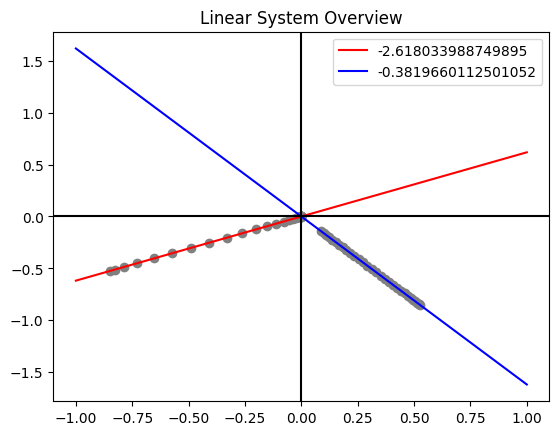

In [173]:
x = np.linspace(-1, 1, 100)
scope = eigvec[1, :] / eigvec[0, :]
plt.plot(x, x*scope[0], color="red", label=eigval[0])
plt.plot(x, x*scope[1], color="blue", label=eigval[1])
get_trajectory(eigvec[:, 0], color="gray")
get_trajectory(eigvec[:, 1], color="gray")
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.title("Linear System Overview")
plt.legend()

$f(w) = 0.5 \times w^T A w - b^Tw$

A is Hessian of f(w). Laplacian is tr(H)=tr(A).

If A is not positive definite(xTAx>0, for all A), the landscape has saddle points.

- Hessian is symmetry (partial derivative)
- PDF is good-defined guy.
- PDF ensures all \lambda > 0 (definition)

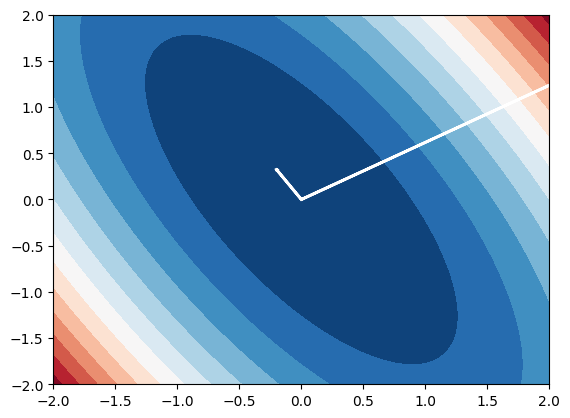

In [209]:
A = np.array([[2, 1], [1, 1]]) # (2, 2)

def draw_hessian(A):
    xi = yi = np.linspace(-2, 2, 100)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = np.zeros_like(Xi)
    for i in range(100):
        for j in range(100):
            xy = np.array([Xi[i][j], Yi[i][j]])
            z = 0.5 * xy.T @ A @ xy
            Zi[i][j] = z

    contour = plt.contourf(Xi, Yi, Zi, levels=15, cmap='RdBu_r', linestyles="--")
    plt.arrow(0, 0, *(eigvec[:, 0]*eigval[0]), color="white", linewidth=2)
    plt.arrow(0, 0, *(eigvec[:, 1]*eigval[1]), color="white", linewidth=2) 
    plt.xlim(-2, 2)
    plt.ylim(-2, 2)

draw_hessian(A)

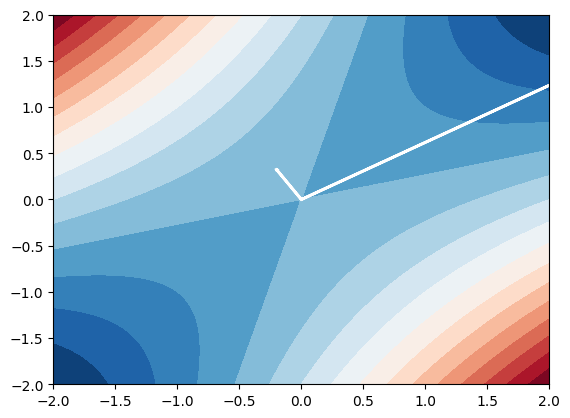

In [210]:
A = np.array([[1, -2], [-2, 1]])
draw_hessian(A)

Graph Laplacian - https://math.stackexchange.com/questions/4089508/intuition-of-the-connection-between-the-graph-laplacian-and-the-laplace-operator

*Quick View*

- The 2nd derivatives helps us figuring out the key of "law of nature" (Laplace equation: Lxx+Lyy=0)
    - minimal surfaces: soap bubbles
    - $m \frac{d^2x}{dt^2}=-k(-x_{i-1}+2x_i-x_{1+1})$ -> Laplacian
    - harmonic property: averaging of neighbor's
- Graph in a linear algebric view!

ps) Any conn with Laplace Transform?

**Spectral Partitioning**

C = C(G): Incidence matrix

Graph Laplacian, L(G) = C^TC (loss the direction)

L(G) = D(egree) - W(adjacency)

- L(G) is symmetry, PDF(wTw!)
- L(G) has real-valued non-negative eigenvalues(PDF) and real-valued orthogonal eigenvectors(why?).
- G has K connected components if and only if $\lambda_0=...=\lambda_{k-1}=0$

from. https://www.youtube.com/watch?v=Vng9lkibGEE



In [227]:
import networkx as nx

nodes = list(range(6))
edges = [(0, 1), (0, 4), (1, 2), (1, 4), (2, 3), (3, 4), (3, 5)]
G = nx.Graph()
G.add_edges_from(edges)

In [279]:
G.adj, G.degree

(AdjacencyView({0: {1: {}, 4: {}}, 1: {0: {}, 2: {}, 4: {}}, 4: {0: {}, 1: {}, 3: {}}, 2: {1: {}, 3: {}}, 3: {2: {}, 4: {}, 5: {}}, 5: {3: {}}}),
 DegreeView({0: 2, 1: 3, 4: 3, 2: 2, 3: 3, 5: 1}))

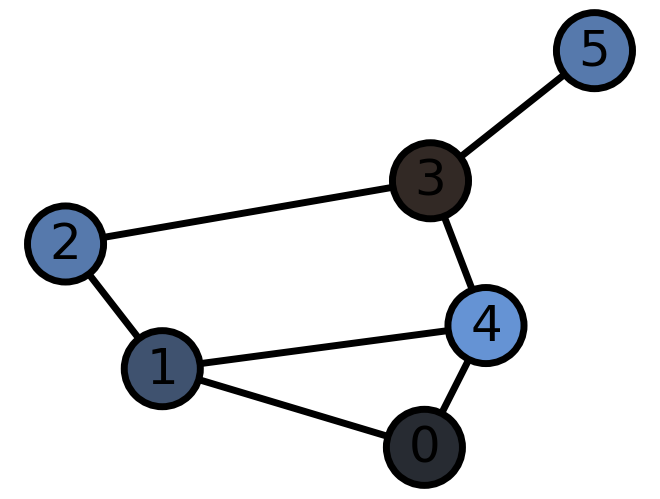

In [368]:
import seaborn as sns

def awesome_graph(w:np.array):
    division = 20
    palette = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True)(np.linspace(0, 1, division))
    node_color = []
    node_w = (np.clip(w*division/2, -division/2+1, division/2-1)+division/2).astype(np.int8)
    for n in G.nodes:
        node_color.append(tuple(palette[node_w[n]]))

    options = {
        "font_size": 36,
        "node_size": 3000,
        "node_color": node_color,
        "edgecolors": "black",
        "linewidths": 5,
        "width": 5,
    }
    return nx.draw(G, with_labels=True, **options)

awesome_graph(np.random.randn(len(G)))

(-0.813056565123073,
 0.5486222271531954,
 -1.0975263374483326,
 1.0480530864149824)

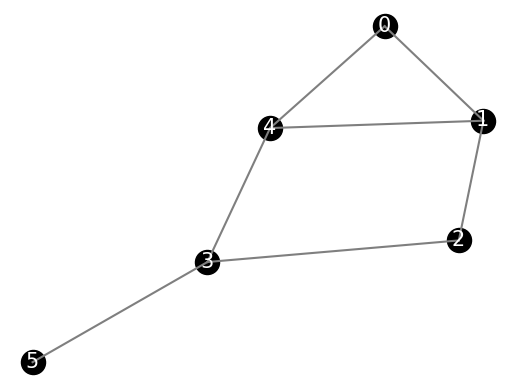

In [364]:
pos = nx.spring_layout(G, dim=2, seed=779)
node_xy = np.array([pos[v] for v in sorted(G)])
edge_xy = np.array([(pos[u], pos[v]) for u, v in G.edges()])


for e in edge_xy:
    plt.plot(*e.T, color="tab:gray")
plt.scatter(*node_xy.T, s=300, color="black")
for x, y, label in zip(*node_xy.T, sorted(G)):
    plt.text(x-0.02, y-0.03, label, {"color": "white", "size": 15})

plt.axis("off")

In [365]:
adj = np.array([[0, 1, 0, 0, 1, 0],
                [1, 0, 1, 0, 1, 0],
                [0, 1, 0, 1, 0, 0],
                [0, 0, 1, 0, 1, 1],
                [1, 1, 0, 1, 0, 0],
                [0, 0, 0, 1, 0, 0]
            ])
degree = np.diag(adj.sum(1))
graph_laplacian = degree - adj

edges = G.edges
total_edges = len(edges)
incidence_matrix = np.zeros((total_edges, len(G)))
starts = [edge[0] for edge in edges]
ends = [edge[1] for edge in edges]
incidence_matrix[range(total_edges), starts] = 1
incidence_matrix[range(total_edges), ends] = -1
np.all(graph_laplacian == incidence_matrix.T @ incidence_matrix) # L(G) = CTC

True

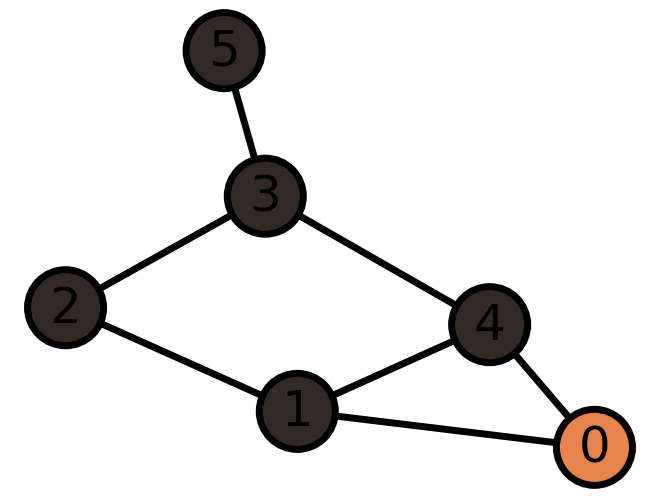

In [369]:
w = np.array([1, 0, 0, 0, 0, 0])
awesome_graph(w)

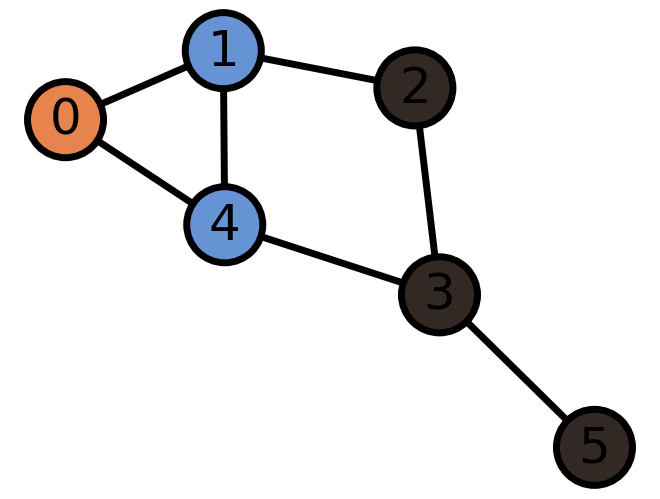

In [372]:
awesome_graph(graph_laplacian @ w)

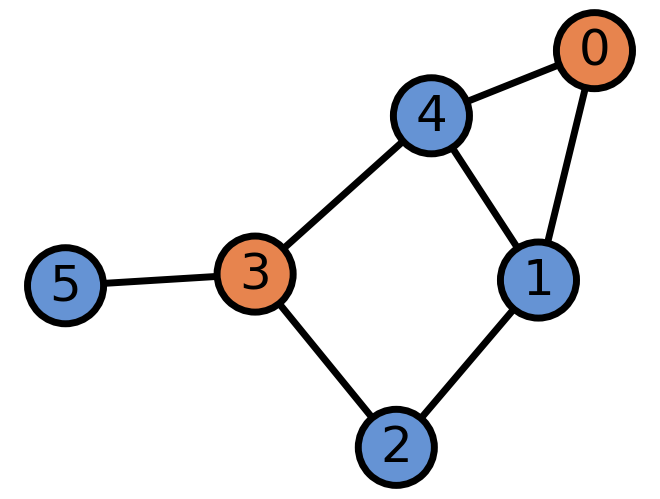

In [381]:
awesome_graph(np.linalg.matrix_power(graph_laplacian, 10) @ w)